# Credit risk EDA — Give Me Some Credit

**Goal:** predict `SeriousDlqin2yrs` — whether a borrower hits 90+ days delinquent within
2 years.


# Credit Default Risk — Notebook Contents

**⭐ = the parts worth your time if you're skimming.**

**1. [Setup & data loading](#Global-Exploratory-Data-analysis)** — imports, load the 150k borrowers. Shape, target balance (6.7% default), missing values.

**2. Exploratory analysis — one section per variable.** The interesting findings:
- ⭐ **[RevolvingUtilization](#RUOUL)** — why values > 1 are *signal*, not error (40% default).
- ⭐ **[DebtRatio](#DebtRatio)** — the discovery that this column hides *two different variables*.
- **[Delinquency counts](#Delinquency)** — the 96/98 indexes.
- **[Other variables](#Other-Variables)** — income, dependents, real-estate loans.

**3. ⭐ [Cleaning decisions](#Data-Cleaning)** — the summary table: every fix, with the evidence behind it. *If you read one thing, read this.*

**4. [Random Forest vs XGBoost](#Comparing-XGBOOST-and-RF)** — ROC-AUC / PR-AUC comparison.

**5. [Threshold & confusion matrices](#Threshold)** — why 0.5 is the wrong cutoff for a rare-event problem.

**6. ⭐ [Conclusion](#Conclusion:-Findings)** — findings, results, and what I'd do next. The business recomendation: reviewing the riskiest 10% catches ~55% of defaulters.

## Global Exploratory Data analysis

A checklist for the first pass. 

- **Shape & types:** `df.shape`, `df.info()`, `df.head()`
- **The target:** 
- **`df.describe()`:** 
- **Count-like / categorical columns:**  `value_counts()` 
- **Missingness:** `df.isnull().sum()`
- **Clean last.**

In [1]:
#pip install kagglehub If kaggle is not installed
#pip install scikit-learn
#!pip install xgboost

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
import os, pandas as pd
#Data available at kaggle website competition Give Me Some credit
path = "/home/axelmb27/.cache/kagglehub/datasets/brycecf/give-me-some-credit-dataset/versions/1"
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "cs-training.csv"), index_col=0)
df.shape

['sampleEntry.csv', 'cs-test.csv', 'cs-training.csv', 'Data Dictionary.xls']


(150000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [5]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [6]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

Let's examine data in this table by variable: 1) Target seems fine, and the binary (0,1) structure is usefull for the mean, it tells that 6.7% of rows (clients) where true in delaying payments serious delinquency in 2 years.  2) Impossible max, 50708 times above credit limit is just wrong. That derives in  a very large std and mean. The percentiles are reasonable. 3)Age seems fine, however there is min in 0 so either is wrong or newborns can have bank accounts, also somene is 109 so good for him/her. 4) Again, impossible max in the data, being 30 days past due 98 times in two years is plainly impossible, that makes mean and std larger, but the majority of data is zero. 5)IMPOSSIBLE MAX maybe someone divided by very small number. (One might assume everyone has monthly income, but it is not a law), therefore average and std very high. Percentiles look plausible and healthy. 6) Less data available, not usual 1.5e+5 entries. Min = 0.0 confirms that not everybody has a monthly income (or maybe it was incorrectly recorded in data). Max = 3 million dollars a month, either somebody very lucky or a wrong capture of data. Mean and std are ok i guess, i am not familiar with the country this data is recorded but 78 k a year might be a little high, considering this are 2011 dollars (thinking in inflation), this might be explained by the high earning outliers. Percentiles look reasonable to me. 7) Data seems fine, except for the max 58 Open lines of credits is very suspicious. Percentiles as usual, look good. 11 might look a little high but considering it is house and car loans + credit cards and more it is still possible. 8) Max is plainly wrong and impossible. 9) Again 54 max is suspicious and quite impossible because it is real estate 10) Max is impossible. 11) Less entries 1.46e+05, very strange the person that has 20 dependents.

In [8]:
df.value_counts()

SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
0                 1.000000                              22   0                                     0.000000   820.0          1                                0                        0                             0                                     0.0                   12
                  0.000000                              22   0                                     0.000000   820.0          2                                0                        0                             0                                     0.0                    8
                  1.000000                              23   0                                     0.000000   820.0          1                                0                   

In [9]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

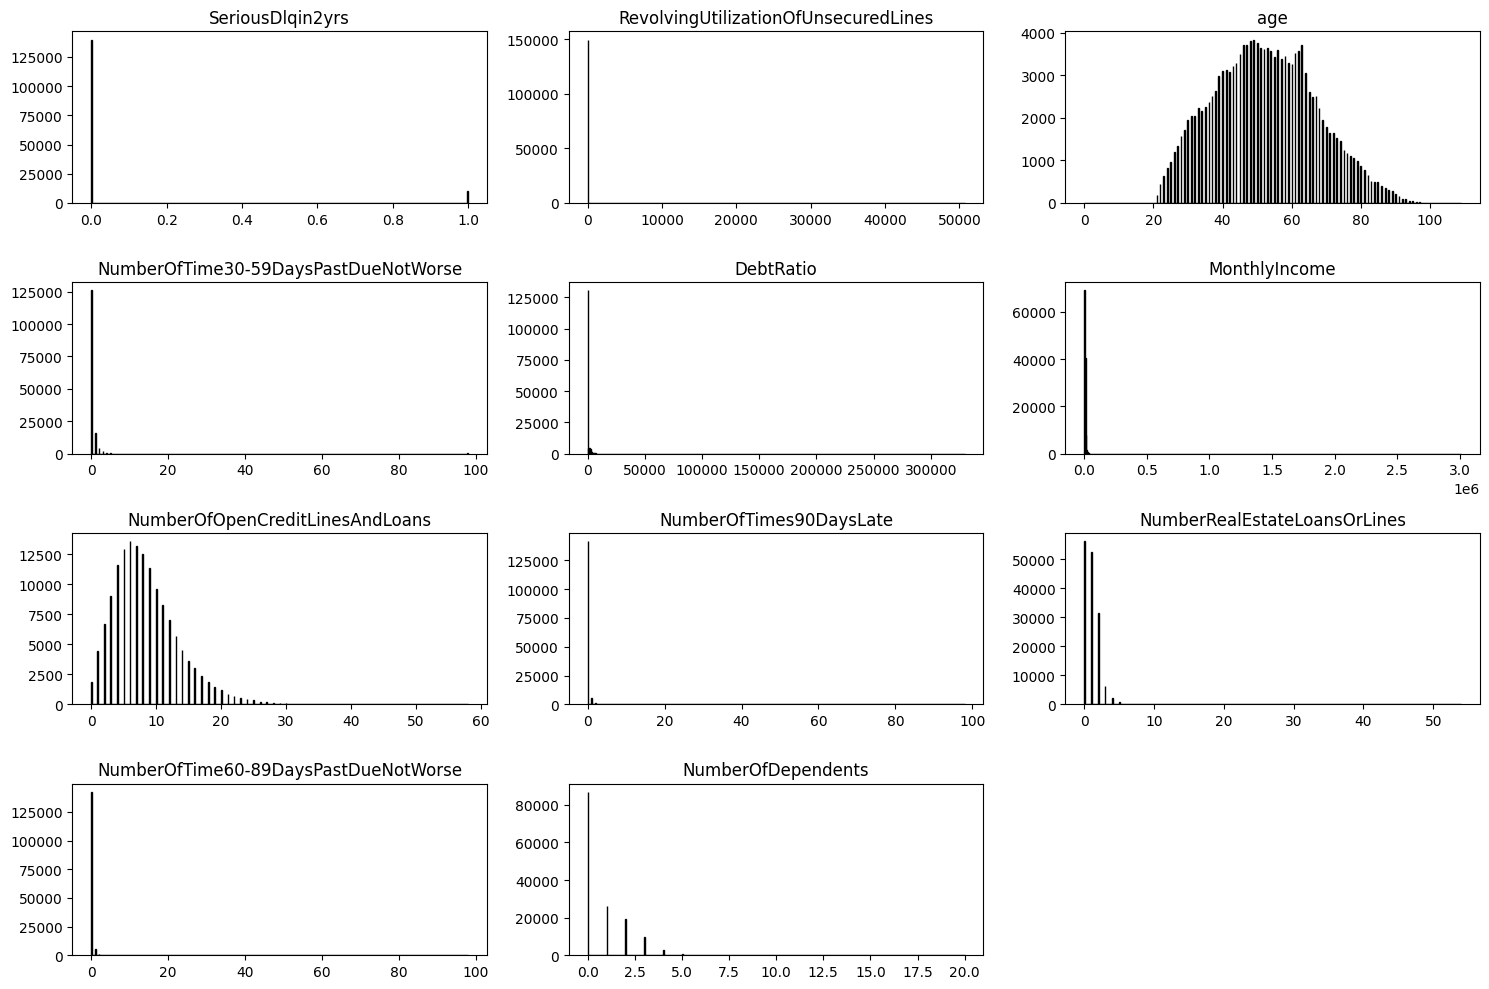

In [10]:
df.hist(figsize=(15, 10), bins=500, edgecolor="black", grid=False)
plt.tight_layout()
plt.show()

This highlights the interesting variables to study. Let's figure out if some have outliers or are hiding crucial information

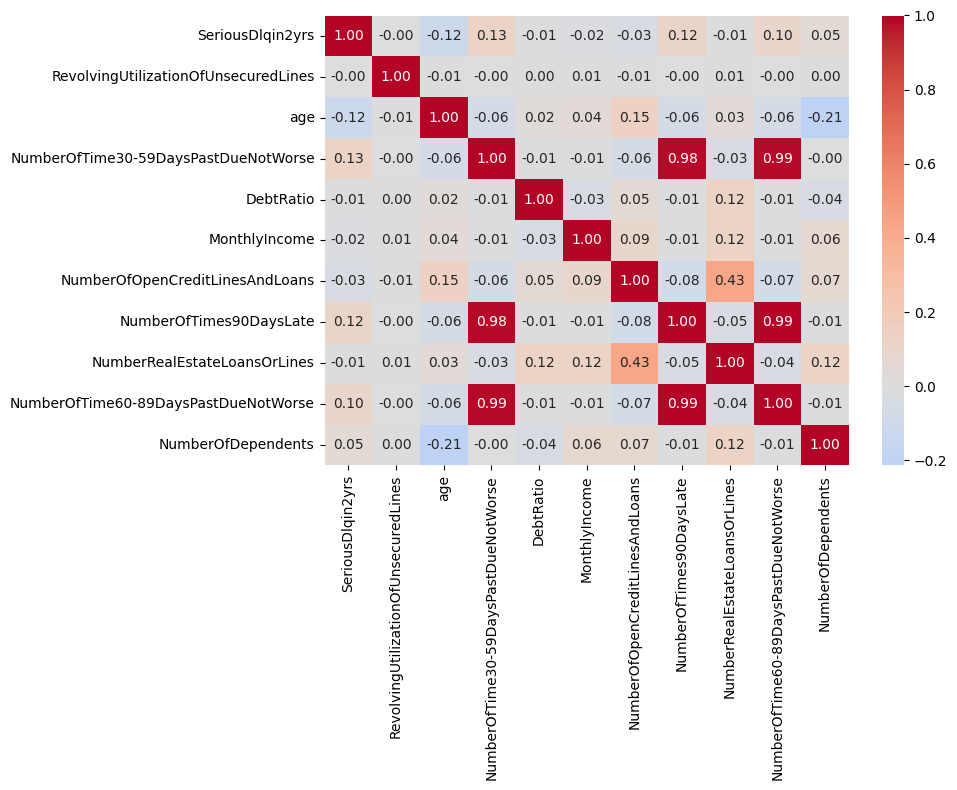

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.tight_layout()
plt.show()

In [12]:
df.groupby('SeriousDlqin2yrs').mean()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
SeriousDlqin2yrs,,,,,,,,,,
0,6.168855,52.751375,0.280109,357.151168,6747.837774,8.493620,0.135225,1.020368,0.126666,0.743417
1,4.367282,45.926591,2.388490,295.121066,5630.826493,7.882306,2.091362,0.988530,1.828047,0.948208


Very Interesting. First of all we are comparing an imbalanced (and still uncleaned) dataset, Target = 1 its 6.7% of total data.  2) Counter intuitive, larger in 0. 3) Maybe unrelated. 4) Possible indicator. 5) Hid by errors. 6) Maybe something to expect, people with lower income have more finantial stress 7) Counter intuitive 8) Very indicative, expected and informative, people with higher number of paying 90 days late have higher chance of being in target = 1. This can be explained by their credit use habits. 9) very similar but also counter intuitive to se lower number in 1.  10) Consistent and indicative 11) very similar and maybe indicative.

## Target Variable

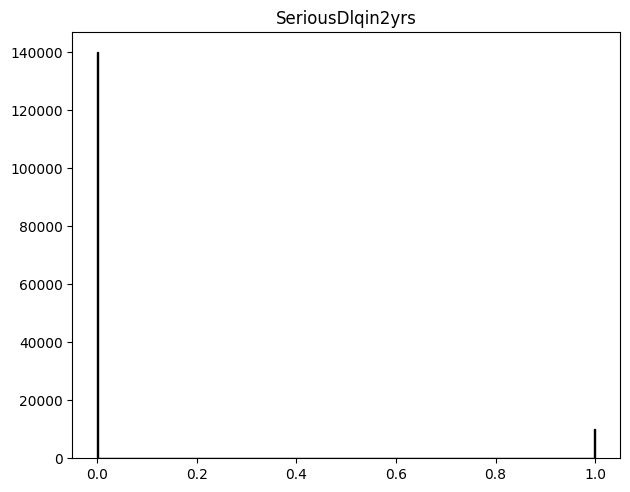

count    150000.000000
mean          0.066840
std           0.249746
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SeriousDlqin2yrs, dtype: float64

In [13]:
df['SeriousDlqin2yrs'].hist(bins=500, edgecolor="black", grid=False)
plt.tight_layout()
plt.title('SeriousDlqin2yrs')
plt.show()
df['SeriousDlqin2yrs'].describe()

## Interesting variables

### RUOUL

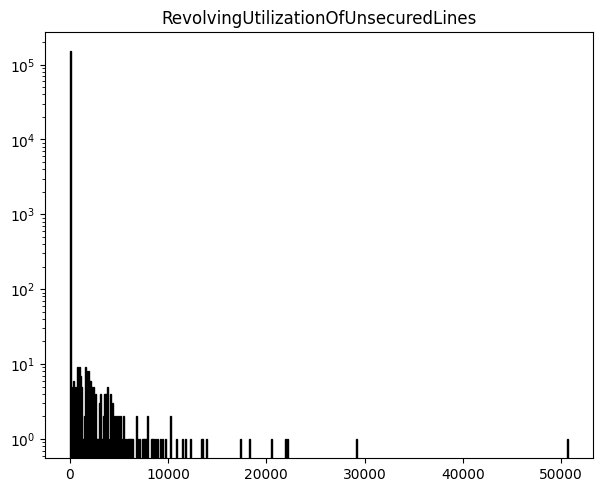

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [14]:
q = df['RevolvingUtilizationOfUnsecuredLines']
q.hist(bins=500, edgecolor="black", grid=False)
plt.tight_layout()
plt.title('RevolvingUtilizationOfUnsecuredLines')
plt.yscale('log')
plt.show()
q.describe()

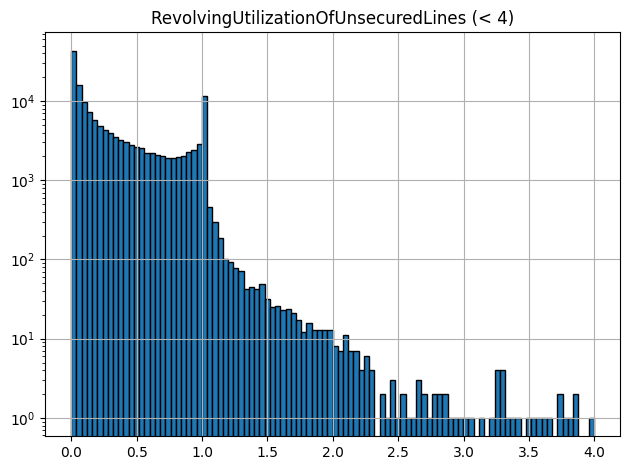

count    149735.000000
mean          0.321951
std           0.360806
min           0.000000
25%           0.029772
50%           0.153492
75%           0.555631
max           3.996008
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [15]:
RUOUL = df.loc[df['RevolvingUtilizationOfUnsecuredLines'] < 4,
               'RevolvingUtilizationOfUnsecuredLines']

RUOUL.hist(bins=100, edgecolor="black", grid=True)
plt.title('RevolvingUtilizationOfUnsecuredLines (< 4)')
plt.yscale('log')
plt.tight_layout()
plt.show()
RUOUL.describe()

In [16]:
print('Total anomalies: ', q.count()-RUOUL.count(), 'Percentage of anomalies : ', (q.count()-RUOUL.count())/q.count())

Total anomalies:  265 Percentage of anomalies :  0.0017666666666666666


<Axes: xlabel='SeriousDlqin2yrs', ylabel='RevolvingUtilizationOfUnsecuredLines'>

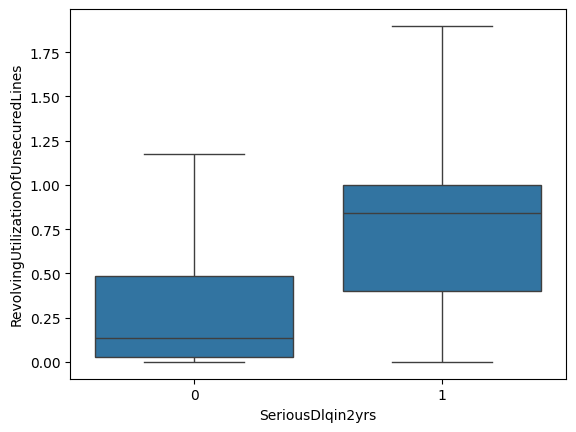

In [17]:
sns.boxplot(x='SeriousDlqin2yrs',y='RevolvingUtilizationOfUnsecuredLines',data=df,showfliers=False)

This variable is: Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits. We have 265 anomalies 0.1% of the total of trainning data.

### NumberOfTime30-59DaysPastDueNotWorse

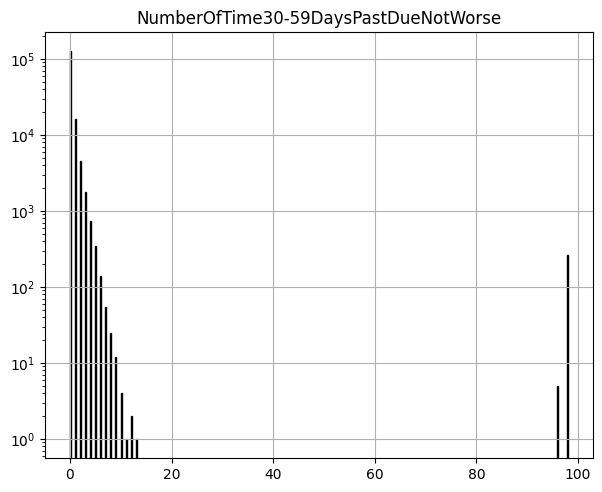

count    150000.000000
mean          0.421033
std           4.192781
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

In [18]:
P = df['NumberOfTime30-59DaysPastDueNotWorse']
P.hist(bins=500, edgecolor="black", grid=True)
plt.tight_layout()
plt.title('NumberOfTime30-59DaysPastDueNotWorse')
plt.yscale('log')
plt.show()
P.describe()

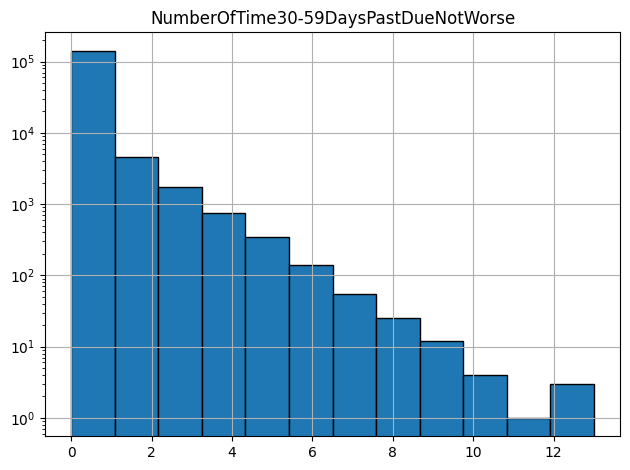

count    149731.000000
mean          0.245794
std           0.697780
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          13.000000
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

In [19]:
NOT59 = df.loc[df['NumberOfTime30-59DaysPastDueNotWorse'] < 24,
               'NumberOfTime30-59DaysPastDueNotWorse']

NOT59.hist(bins=12, edgecolor="black", grid=True)
plt.title('NumberOfTime30-59DaysPastDueNotWorse')
plt.yscale('log')
plt.tight_layout()
plt.show()
NOT59.describe()

In [20]:
print('Total anomalies: ', P.count()-NOT59.count(), 'Percentage of anomalies : ', (P.count()-NOT59.count())/NOT59.count())

Total anomalies:  269 Percentage of anomalies :  0.001796555155579005


<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfTime30-59DaysPastDueNotWorse'>

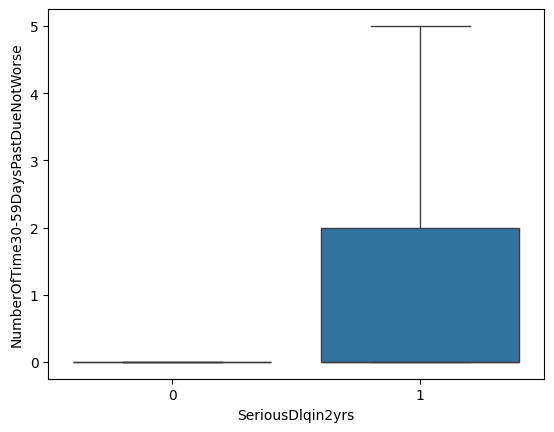

In [21]:
sns.boxplot(x='SeriousDlqin2yrs',y='NumberOfTime30-59DaysPastDueNotWorse',data=df,showfliers=False)

This variable is Number of times borrower has been 30-59 days past due but no worse in the last 2 years. There are some impossible numbers because it cannot have a value of 98 in two years. 

### DebtRatio

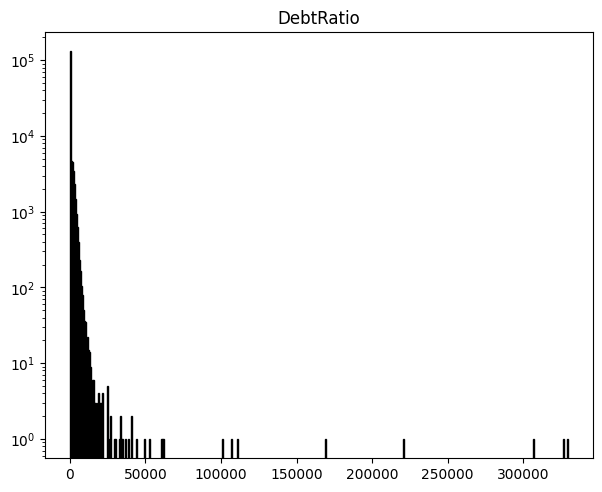

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

In [22]:
qdr = df['DebtRatio']
qdr.hist(bins=500, edgecolor="black", grid=False)
plt.tight_layout()
plt.title('DebtRatio')
plt.yscale('log')
plt.show()
qdr.describe()

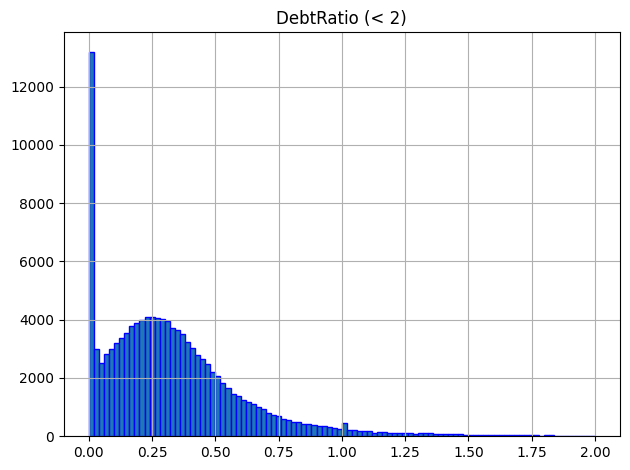

count    118785.000000
mean          0.336189
std           0.289530
min           0.000000
25%           0.131991
50%           0.284303
75%           0.460273
max           1.998765
Name: DebtRatio, dtype: float64

In [23]:
D_rat = df.loc[df['DebtRatio'] < 2,
               'DebtRatio']

D_rat.hist(bins=100, edgecolor="blue", grid=True)
plt.title('DebtRatio (< 2)')
#plt.yscale('log')
plt.tight_layout()
plt.show()
D_rat.describe()

In [24]:
print('Total anomalies: ', qdr.count()-D_rat.count(), 'Percentage of anomalies : ', (qdr.count()-D_rat.count())/qdr.count())

Total anomalies:  31215 Percentage of anomalies :  0.2081


<Axes: xlabel='SeriousDlqin2yrs', ylabel='DebtRatio'>

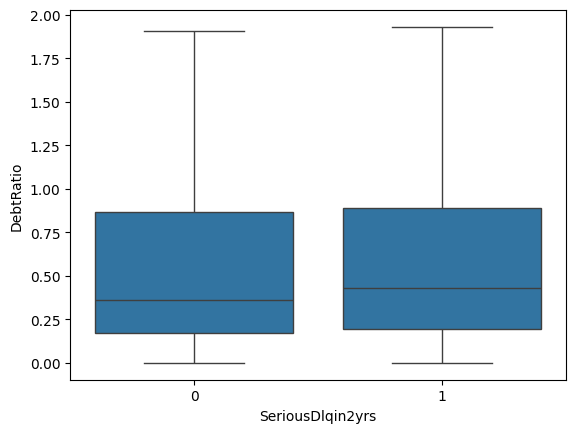

In [25]:
sns.boxplot(x='SeriousDlqin2yrs',y='DebtRatio',data=df,showfliers=False)

This variable is: Monthly debt payments, alimony,living costs divided by monthy gross income. It is a bit worrying that being a percentage it has a large amount of anomalies Around 23% of data, those should not be outliers but some inconsistency inside the thata, let's explore them:

#### Debt Ratio: Two variables in one column

In [26]:
no_income = df["MonthlyIncome"].isnull() | (df["MonthlyIncome"] == 0)
suspect   = df["DebtRatio"] > 1

# 1) Wrong debt ratio correspond to no income?
ct = pd.crosstab(suspect, no_income, normalize="index").round(3)
ct.index = ["DebtRatio <= 1", "DebtRatio > 1"]; ct.columns = ["has income", "No income"]
print(ct, "\n")

# 2) DO they look like income?
print(df.loc[suspect, "DebtRatio"].describe(percentiles=[.25,.5,.75]).round(1), "\n")

# 3) DO they have a signal into target?
base = df.SeriousDlqin2yrs.mean()
for u in [1, 100, 1000]:
    g = df.DebtRatio > u
    print(f"> {u:>5}: n={g.sum():>6}  default={df.loc[g,'SeriousDlqin2yrs'].mean():.3f} ({df.loc[g,'SeriousDlqin2yrs'].mean()/base:.2f}x)")
print(f"base: {base:.3f}")

                has income  No income
DebtRatio <= 1       0.983      0.017
DebtRatio > 1        0.163      0.837 

count     35137.0
mean       1506.0
std        3999.0
min           1.0
25%          42.0
50%         907.0
75%        2210.0
max      329664.0
Name: DebtRatio, dtype: float64 

>     1: n= 35137  default=0.065 (0.98x)
>   100: n= 24380  default=0.058 (0.87x)
>  1000: n= 16892  default=0.049 (0.73x)
base: 0.067


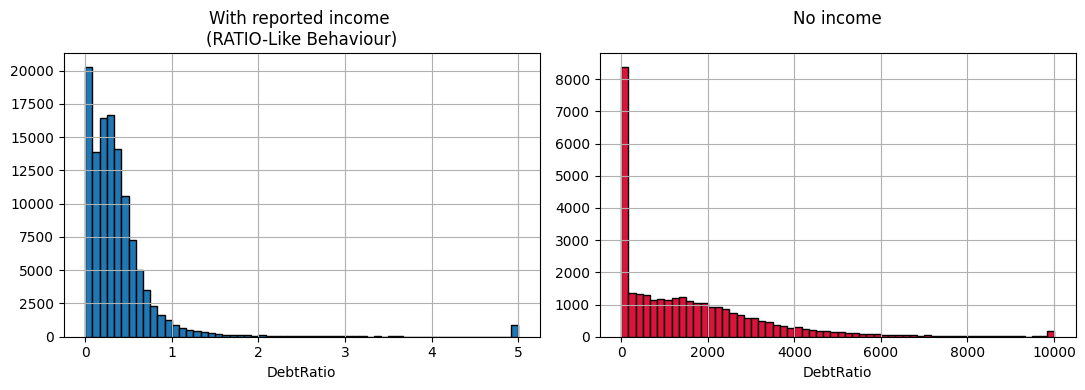

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df.loc[~no_income, "DebtRatio"].clip(upper=5).hist(bins=60, ax=axes[0], edgecolor="black")
axes[0].set_title("With reported income \n(RATIO-Like Behaviour)"); axes[0].set_xlabel("DebtRatio")
df.loc[no_income, "DebtRatio"].clip(upper=10000).hist(bins=60, ax=axes[1], color="crimson", edgecolor="black")
axes[1].set_title("No income\n"); axes[1].set_xlabel("DebtRatio")
plt.tight_layout(); plt.show()

First: 83.7% of Debt Ratio > 1 entries correspond to No income class! So remember $\text{Debt Ratio} = \text{Debt}/\text{Monthly Income}$, if denominator is zero it just records the Debt in the data. Second: The distribution of this numbers might look like monthly debt payments. Third: There is almost no signal with this part of the data, so cleaning them should not mess with a model's results.

### Monthly Income

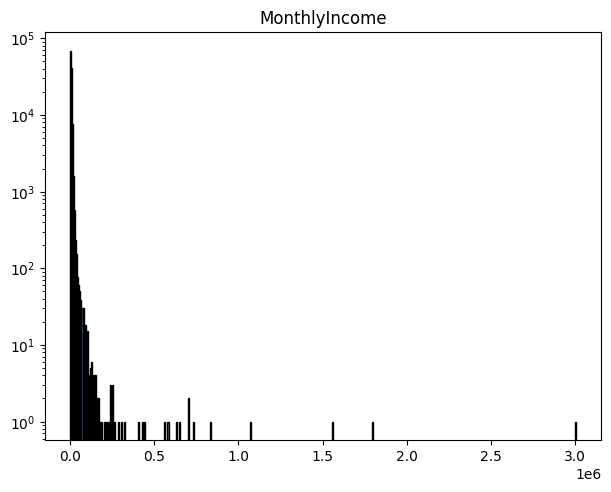

<class 'pandas.core.series.Series'>
Index: 150000 entries, 1 to 150000
Series name: MonthlyIncome
Non-Null Count   Dtype  
--------------   -----  
120269 non-null  float64
dtypes: float64(1)
memory usage: 2.3 MB


np.int64(29731)

In [28]:
qmi = df['MonthlyIncome']
qmi.hist(bins=500, edgecolor="black", grid=False)
plt.tight_layout()
plt.title('MonthlyIncome')
plt.yscale('log')
plt.show()
qmi.describe()
qmi.info()
qmi.isnull().sum()

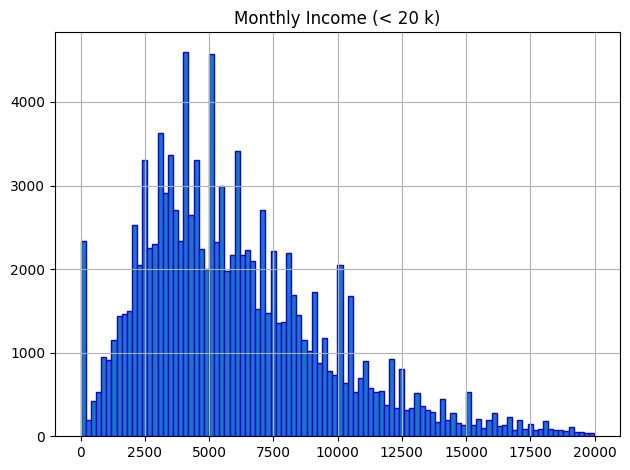

count    117940.000000
mean       6010.371121
std        3656.648908
min           0.000000
25%        3348.000000
50%        5300.000000
75%        8000.000000
max       19989.000000
Name: MonthlyIncome, dtype: float64

In [29]:
MI = df.loc[df['MonthlyIncome'] < 2.000e+04,
               'MonthlyIncome']

MI.hist(bins=100, edgecolor="blue", grid=True)
plt.title('Monthly Income (< 20 k)')
#plt.yscale('log')
plt.tight_layout()
plt.show()
MI.describe()

In [30]:
print('Total anomalies: ', qmi.count()-MI.count(), 'Percentage of anomalies : ', (qmi.count()-MI.count())/qmi.count())

Total anomalies:  2329 Percentage of anomalies :  0.01936492362953047


In [31]:
print('Original data : ','sum of nulls : ', qmi.isnull().sum(), 'Percentage: ',  qmi.isnull().sum()/150000)

Original data :  sum of nulls :  29731 Percentage:  0.19820666666666667


In [32]:
MI.isnull().sum()

np.int64(0)

<Axes: xlabel='SeriousDlqin2yrs', ylabel='MonthlyIncome'>

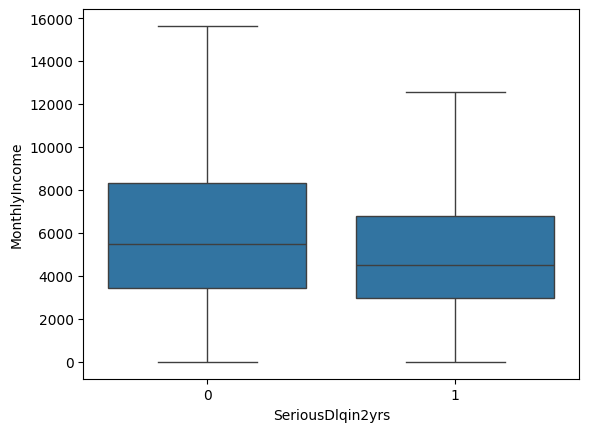

In [33]:
sns.boxplot(x='SeriousDlqin2yrs',y='MonthlyIncome',data=df,showfliers=False)

Variable is self explanatory, however original data has very large amount of null : approx 30 k. 19 % of the data!

### NumberOfTimes90DaysLate

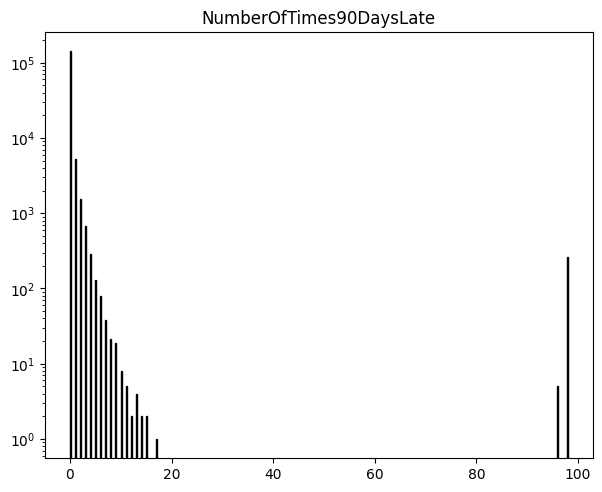

describe:  count    150000.000000
mean          0.265973
std           4.169304
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTimes90DaysLate, dtype: float64 isnull:  0


In [34]:
q90 = df['NumberOfTimes90DaysLate']
q90.hist(bins=500, edgecolor="black", grid=False)
plt.tight_layout()
plt.title('NumberOfTimes90DaysLate')
plt.yscale('log')
plt.show()
print('describe: ', q90.describe(), 'isnull: ', q90.isnull().sum())

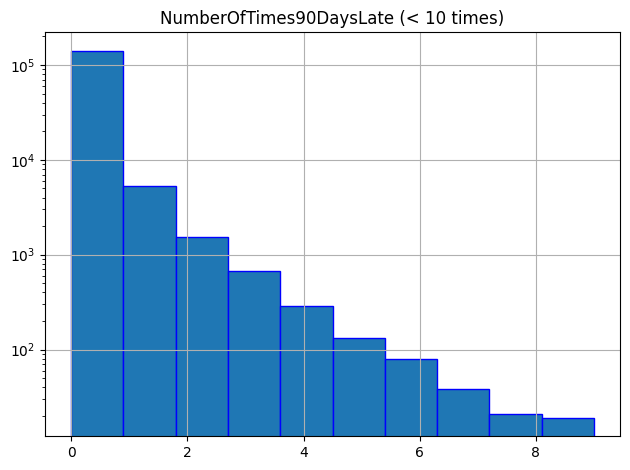

count    149707.000000
mean          0.088560
std           0.461233
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: NumberOfTimes90DaysLate, dtype: float64

In [35]:
N90 = df.loc[df['NumberOfTimes90DaysLate'] < 10,
               'NumberOfTimes90DaysLate']

N90.hist(bins=10, edgecolor="blue", grid=True)
plt.title('NumberOfTimes90DaysLate (< 10 times)')
plt.yscale('log')
plt.tight_layout()
plt.show()
N90.describe()

In [36]:
print('Total anomalies: ', q90.count()-N90.count(), 'Percentage of anomalies : ', (q90.count()-N90.count())/q90.count())

Total anomalies:  293 Percentage of anomalies :  0.0019533333333333334


<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfTimes90DaysLate'>

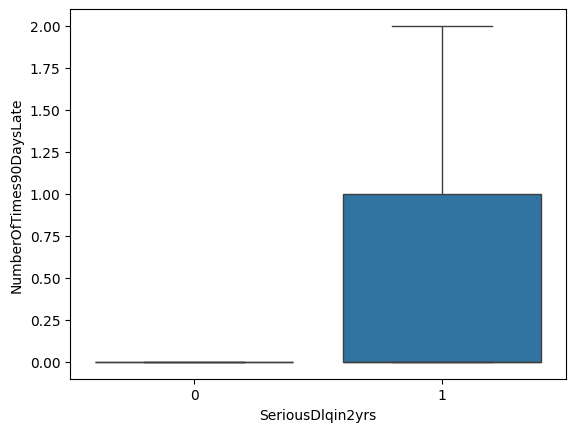

In [37]:
sns.boxplot(x='SeriousDlqin2yrs',y='NumberOfTimes90DaysLate',data=df,showfliers=False)

This variable is self-explanatory as well. Very few but existent anomalies with impossible values of 90 times, unreallistic. It appears consistent.

### NumberRealEstateLoansOrLines

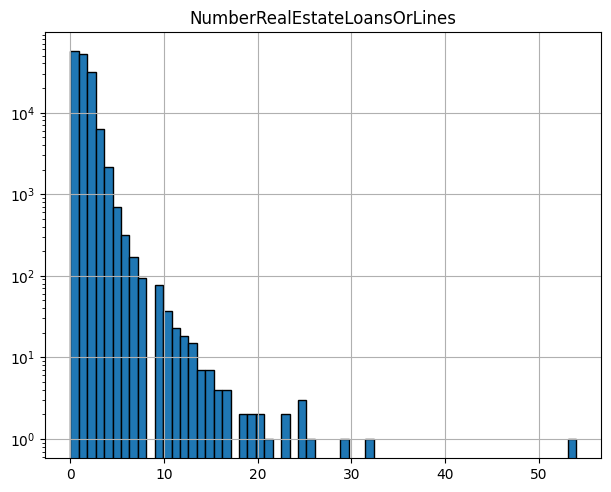

describe:  count    150000.000000
mean          1.018240
std           1.129771
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          54.000000
Name: NumberRealEstateLoansOrLines, dtype: float64 isnull:  0


In [38]:
qrst = df['NumberRealEstateLoansOrLines']
qrst.hist(bins=60, edgecolor="black", grid=True)
plt.tight_layout()
plt.title('NumberRealEstateLoansOrLines')
plt.yscale('log')
plt.show()
print('describe: ', qrst.describe(), 'isnull: ', qrst.isnull().sum())

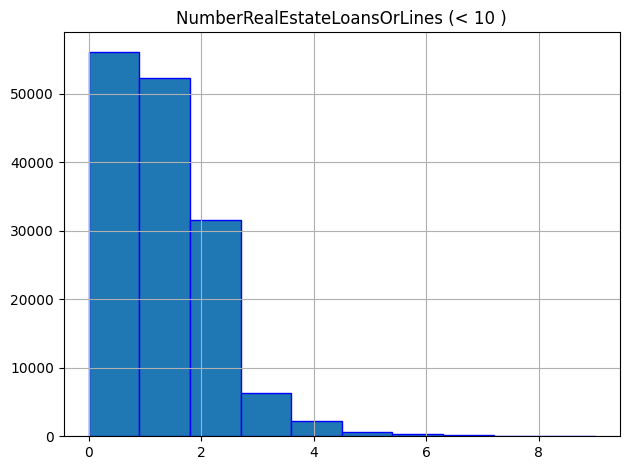

count    149869.000000
mean          1.007346
std           1.056119
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           9.000000
Name: NumberRealEstateLoansOrLines, dtype: float64

In [39]:
Nre = df.loc[df['NumberRealEstateLoansOrLines'] < 10,
               'NumberRealEstateLoansOrLines']

Nre.hist(bins=10, edgecolor="blue", grid=True)
plt.title('NumberRealEstateLoansOrLines (< 10 )')
#plt.yscale('log')
plt.tight_layout()
plt.show()
Nre.describe()

In [40]:
print('Total anomalies: ', qrst.count()-Nre.count(), 'Percentage of anomalies : ', (qrst.count()-Nre.count())/qrst.count())

Total anomalies:  131 Percentage of anomalies :  0.0008733333333333334


<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberRealEstateLoansOrLines'>

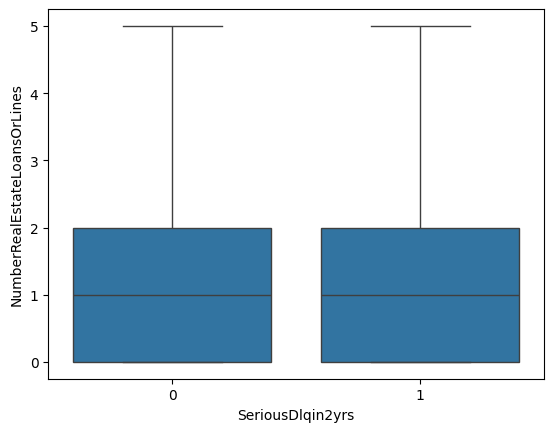

In [41]:
sns.boxplot(x='SeriousDlqin2yrs',y='NumberRealEstateLoansOrLines',data=df,showfliers=False)

This varible is self-explanatory. Very few anomalies so very clean.

### NumberOfTime60-89DaysPastDueNotWorse

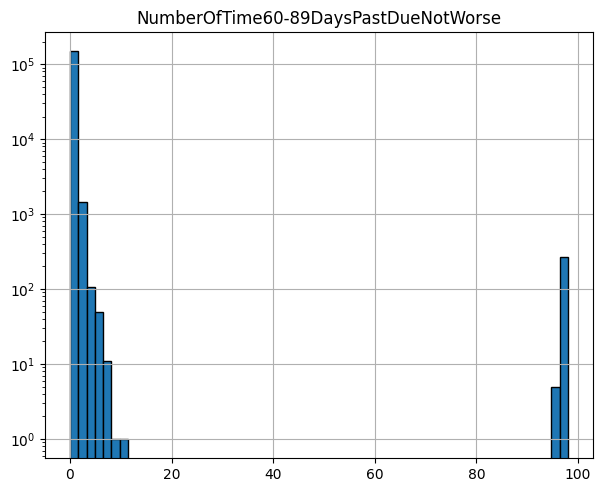

describe:  count    150000.000000
mean          0.240387
std           4.155179
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: float64 isnull:  0


In [42]:
q60 = df['NumberOfTime60-89DaysPastDueNotWorse']
q60.hist(bins=60, edgecolor="black", grid=True)
plt.tight_layout()
plt.title('NumberOfTime60-89DaysPastDueNotWorse')
plt.yscale('log')
plt.show()
print('describe: ', q60.describe(), 'isnull: ', q60.isnull().sum())

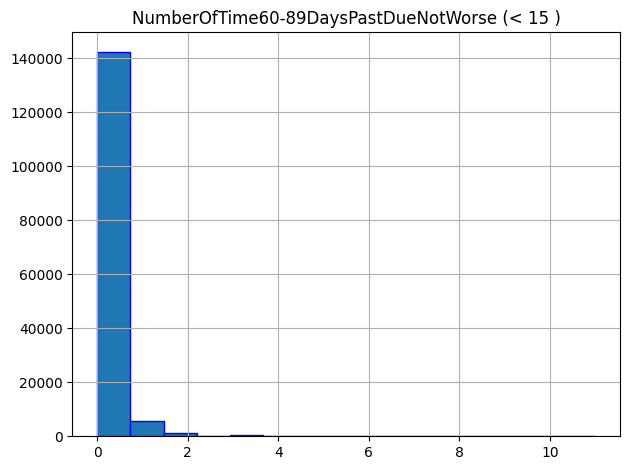

count    149731.000000
mean          0.064823
std           0.330073
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          11.000000
Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: float64

In [43]:
N60 = df.loc[df['NumberOfTime60-89DaysPastDueNotWorse'] < 15,
               'NumberOfTime60-89DaysPastDueNotWorse']

N60.hist(bins=15, edgecolor="blue", grid=True)
plt.title('NumberOfTime60-89DaysPastDueNotWorse (< 15 )')
#plt.yscale('log')
plt.tight_layout()
plt.show()
N60.describe()

In [44]:
print('Total anomalies: ', q60.count()-N60.count(), 'Percentage of anomalies : ', (q60.count()-N60.count())/q60.count())

Total anomalies:  269 Percentage of anomalies :  0.0017933333333333334


<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfTime60-89DaysPastDueNotWorse'>

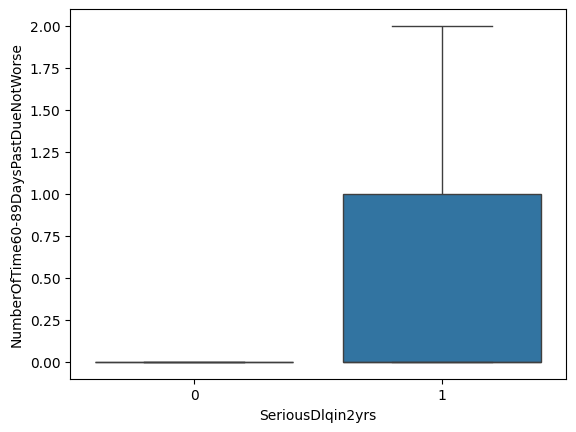

In [45]:
sns.boxplot(x='SeriousDlqin2yrs',y='NumberOfTime60-89DaysPastDueNotWorse',data=df,showfliers=False)

## Como predicen el Target = 1 los outliers de cada variable interesante?

In [46]:
base = df['SeriousDlqin2yrs'].mean()

umbrales = {
    'RevolvingUtilizationOfUnsecuredLines': 4,
    'NumberOfTime30-59DaysPastDueNotWorse': 24,
    'DebtRatio': 2,
    'MonthlyIncome': 20000,
    'NumberOfTimes90DaysLate': 10,
    'NumberRealEstateLoansOrLines': 10,
    'NumberOfTime60-89DaysPastDueNotWorse': 15,
}

filas = []
for col, umbral in umbrales.items():
    out = df[col] > umbral          # los "outliers"
    normal = df[col] <= umbral      # los normales
    filas.append({
        'variable': col,
        'n_outliers': out.sum(),
        'default_normales': df.loc[normal, 'SeriousDlqin2yrs'].mean(),
        'default_outliers': df.loc[out, 'SeriousDlqin2yrs'].mean(),
    })

tabla = pd.DataFrame(filas)
tabla['veces_vs_base'] = tabla['default_outliers'] / base
print(tabla.round(3))

                               variable  n_outliers  default_normales  \
0  RevolvingUtilizationOfUnsecuredLines         264             0.067   
1  NumberOfTime30-59DaysPastDueNotWorse         269             0.066   
2                             DebtRatio       31045             0.070   
3                         MonthlyIncome        2103             0.070   
4               NumberOfTimes90DaysLate         285             0.066   
5          NumberRealEstateLoansOrLines          94             0.067   
6  NumberOfTime60-89DaysPastDueNotWorse         269             0.066   

   default_outliers  veces_vs_base  
0             0.087          1.303  
1             0.546          8.176  
2             0.056          0.844  
3             0.053          0.797  
4             0.544          8.137  
5             0.223          3.342  
6             0.546          8.176  


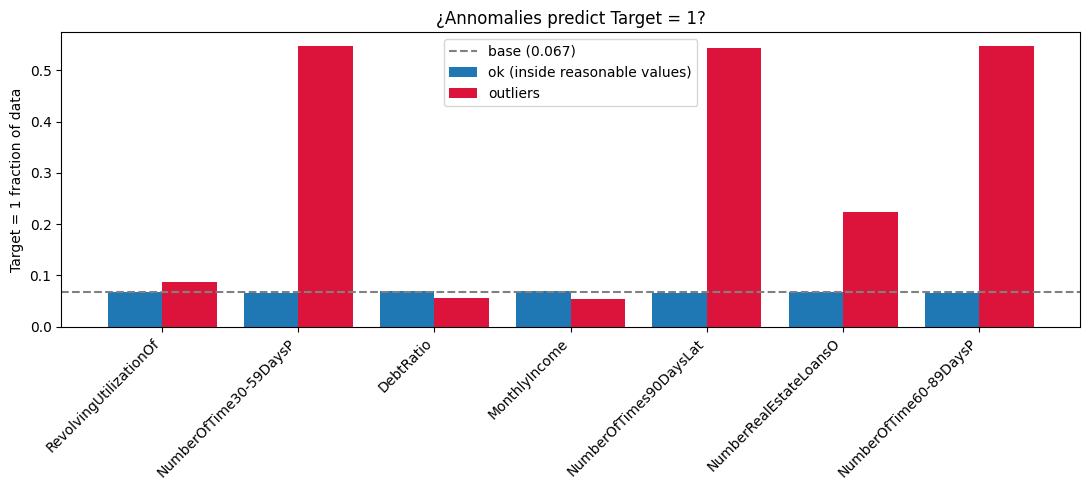

In [47]:
x = np.arange(len(tabla))
plt.figure(figsize=(11, 5))
plt.bar(x - 0.2, tabla['default_normales'], 0.4, label='ok (inside reasonable values)')
plt.bar(x + 0.2, tabla['default_outliers'], 0.4, label='outliers', color='crimson')
plt.axhline(base, ls='--', color='gray', label=f'base ({base:.3f})')
plt.xticks(x, [c[:22] for c in tabla['variable']], rotation=45, ha='right')
plt.ylabel('Target = 1 fraction of data')
plt.title('¿Annomalies predict Target = 1?')
plt.legend(); plt.tight_layout(); plt.show()

This is very informative, 90  days late, 30-59 days late, 60-89 days late and number of real estate loans! My first reading of this was: My umbral is pretty good at detecting delinquent default in clients! At least in these four variables right?. The umbral or prediction is the model's work. My afterthought reading is: Do not discard outliers because they have sometimes inmense predicting capability, just errasing rows because they have impossible numbers would be a disaster for a predictive model!

In [48]:
u = df['RevolvingUtilizationOfUnsecuredLines']
for umbral in [1, 2, 5, 13, 100, 1000]:
    g = u > umbral
    print(f"> {umbral:>5}: n={g.sum():>5} default={df.loc[g,'SeriousDlqin2yrs'].mean():.3f} "
          f"({df.loc[g,'SeriousDlqin2yrs'].mean()/base:.1f}x)")
print(f"base: {base:.3f}")

>     1: n= 3321 default=0.372 (5.6x)
>     2: n=  371 default=0.146 (2.2x)
>     5: n=  254 default=0.079 (1.2x)
>    13: n=  238 default=0.059 (0.9x)
>   100: n=  223 default=0.049 (0.7x)
>  1000: n=  172 default=0.058 (0.9x)
base: 0.067


This tells us that the larger the umbral the more signal we loose, for umbrals larger than $\approx 1-2$ we have noise.

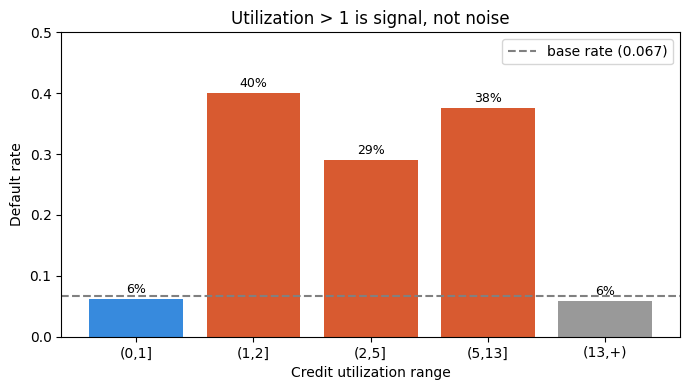

In [49]:
base = df['SeriousDlqin2yrs'].mean()
u = df['RevolvingUtilizationOfUnsecuredLines']

# Signalby group
ranges = [("(0,1]", (0, 1)), ("(1,2]", (1, 2)), ("(2,5]", (2, 5)),
          ("(5,13]", (5, 13)), ("(13,+)", (13, 1e9))]

labels, rates = [], []
for lab, (lo, hi) in ranges:
    g = (u > lo) & (u <= hi)
    rates.append(df.loc[g, 'SeriousDlqin2yrs'].mean())
    labels.append(lab)

plt.figure(figsize=(7, 4))
colors = ["#378ADD", "#D85A30", "#D85A30", "#D85A30", "#999999"]
bars = plt.bar(labels, rates, color=colors)
plt.axhline(base, ls="--", color="gray", label=f"base rate ({base:.3f})")
plt.ylabel("Default rate")
plt.ylim(0,0.50)
plt.xlabel("Credit utilization range")
plt.title("Utilization > 1 is signal, not noise")
plt.legend()
for b, r in zip(bars, rates):
    plt.text(b.get_x() + b.get_width()/2, r + 0.01, f"{r:.0%}", ha="center", fontsize=9)
plt.tight_layout()
#plt.savefig("./figures/01_utilization_signal.png", dpi=110)   # guarda para el README
plt.show()

In this part I learned that banks let borrowers go over their credit limit. Even if utilization was 4, 5, or even 13 times the limit (which is suspiciously large but might be for a dynamic adjustment of limits vs total debt) over-the-limit borrowers still defaulted at 3-6 times the base rate!

# Data Cleaning

In [50]:
data = df.copy()

PAY_COLS = ["NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
            "NumberOfTime60-89DaysPastDueNotWorse"]
data["late_sentinel"]      = data["NumberOfTimes90DaysLate"].isin([96, 98]).astype(int)
data["income_missing"]     = data["MonthlyIncome"].isnull().astype(int)
data["dependents_missing"] = data["NumberOfDependents"].isnull().astype(int)

# ---------- 1. Values 96/98
# Imposible number but riskiests rows
# change for real max in every column
for c in PAY_COLS:
    real_max = data.loc[~data[c].isin([96, 98]), c].max()
    data.loc[data[c].isin([96, 98]), c] = real_max

# ---------- 2. age == 0 impossible
data.loc[data["age"] == 0, "age"] = np.nan

# ---------- 3. RUOUL: max ----------
# up to ~13
data["RevolvingUtilizationOfUnsecuredLines"] = \
    data["RevolvingUtilizationOfUnsecuredLines"].clip(upper=13)

# ---------- 4. DebtRatio: separar las DOS variables ----------
# 83.7% of DebtRatio > 1 rows with no Income
sin_ingreso = data["MonthlyIncome"].isnull() | (data["MonthlyIncome"] == 0)
data["debt_amount"] = np.where(sin_ingreso, data["DebtRatio"], 0)  
data.loc[sin_ingreso, "DebtRatio"] = np.nan                         
data["DebtRatio"] = data["DebtRatio"].clip(upper=3)                

# ---------- 5. Median ----------
for c in ["MonthlyIncome", "DebtRatio", "age"]:
    data[c] = data[c].fillna(data[c].median())
data["NumberOfDependents"] = data["NumberOfDependents"].fillna(0)

# ---------- Verify ----------
print("remaining nulls:", int(data.isnull().sum().sum()))    # -> 0
print("\nDEFAULT MAX ( 13, 17, 11 no 98):")
print(data[PAY_COLS].max())
print("\nrows:", len(data), "| new columns:", 
      [c for c in data.columns if c not in df.columns])

remaining nulls: 0

DEFAULT MAX ( 13, 17, 11 no 98):
NumberOfTime30-59DaysPastDueNotWorse    13
NumberOfTimes90DaysLate                 17
NumberOfTime60-89DaysPastDueNotWorse    11
dtype: int64

rows: 150000 | new columns: ['late_sentinel', 'income_missing', 'dependents_missing', 'debt_amount']


# Model implementation and evaluation

## Random Forest

In [51]:
import time
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier   # Classifier, no Regressor
from sklearn.metrics import roc_auc_score, average_precision_score

# features and target 
X = data.drop(columns=["SeriousDlqin2yrs"])
y = data["SeriousDlqin2yrs"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Observaciones train:", X_train.shape[0], "| test:", X_test.shape[0])
print("Default rate — train:", round(y_train.mean(),4), "| test:", round(y_test.mean(),4))

# pipeline
rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42,
                                     class_weight="balanced", n_jobs=-1)),
])

# time
start_time_rf = time.time()
rf.fit(X_train, y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf

# predict probability
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# classification metrics
roc_rf = roc_auc_score(y_test, y_proba_rf)
pr_rf  = average_precision_score(y_test, y_proba_rf)

print(f'\nRandom Forest:  ROC-AUC = {roc_rf:.4f}, PR-AUC = {pr_rf:.4f}')
print(f'Random Forest:  Training Time = {rf_train_time:.3f} seconds')
print(f'no-skill (base):  PR-AUC = {y_test.mean():.4f}')

Observaciones train: 105000 | test: 45000
Default rate — train: 0.0668 | test: 0.0668

Random Forest:  ROC-AUC = 0.8337, PR-AUC = 0.3505
Random Forest:  Training Time = 1.673 seconds
no-skill (base):  PR-AUC = 0.0668


treshold     TP     FN      FP  precision   recall
    0.5    438   2570     341      0.562    0.146
    0.3   1048   1960    1281      0.450    0.348
    0.2   1463   1545    2446      0.374    0.486
    0.1   1972   1036    5795      0.254    0.656


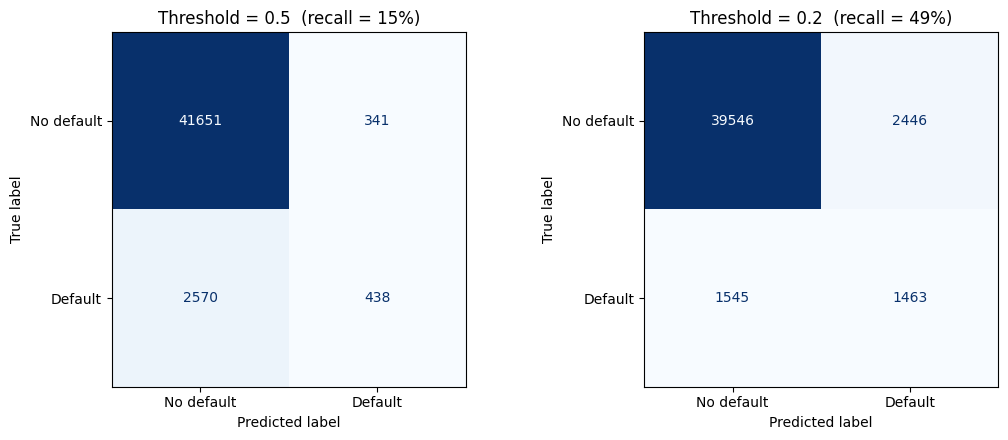

              precision    recall  f1-score   support

  No default      0.962     0.942     0.952     41992
     Default      0.374     0.486     0.423      3008

    accuracy                          0.911     45000
   macro avg      0.668     0.714     0.687     45000
weighted avg      0.923     0.911     0.917     45000



In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

proba = rf.predict_proba(X_test)[:, 1]   # probabilidad de default

# Table: threshold variability
print(f"{'treshold':>7} {'TP':>6} {'FN':>6} {'FP':>7} {'precision':>10} {'recall':>8}")
for t in [0.5, 0.3, 0.2, 0.1]:
    pred = (proba > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{t:>7} {tp:>6} {fn:>6} {fp:>7} {tp/(tp+fp):>10.3f} {tp/(tp+fn):>8.3f}")

# COnfussion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, t in zip(axes, [0.5, 0.2]):
    pred = (proba > t).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Threshold = {t}  (recall = {cm[1,1]/y_test.sum():.0%})")
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba > 0.2).astype(int),
                            target_names=["No default", "Default"], digits=3))

Very Interesting results, the model's hability to predict default in payments is highly sensitive to threshold, and here we have to balance True Positives, False Negatives and False Positives. The main objective of this is to find a threshold that 'catches' the max number of Default clients without declining clients that are going to pay. $\textbf{Deciding to label as Default every client with a probability higher  than 0.2 of Defaulting seems to be optimal.}$ $\textbf{By minimizing False Positive and maximizing True Positive.}$

## XGBOOST

In [53]:
from xgboost import XGBClassifier

# scale_pos_weight = negatives for every possitive
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos, 1))

xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                            subsample=0.9, colsample_bytree=0.9,
                            scale_pos_weight=scale_pos, eval_metric="aucpr",
                            n_jobs=-1, random_state=42)),
])

start_time_xgb = time.time()
xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start_time_xgb

proba_rf  = rf.predict_proba(X_test)[:, 1]
proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(f'Random Forest:  ROC-AUC = {roc_auc_score(y_test, proba_rf):.4f}, '
      f'PR-AUC = {average_precision_score(y_test, proba_rf):.4f}, '
      f'Time = {rf_train_time:.2f}s')
print(f'      XGBoost:  ROC-AUC = {roc_auc_score(y_test, proba_xgb):.4f}, '
      f'PR-AUC = {average_precision_score(y_test, proba_xgb):.4f}, '
      f'Time = {xgb_train_time:.2f}s')
print(f'     no-skill:  PR-AUC = {y_test.mean():.4f}')

scale_pos_weight: 14.0
Random Forest:  ROC-AUC = 0.8337, PR-AUC = 0.3505, Time = 1.67s
      XGBoost:  ROC-AUC = 0.8655, PR-AUC = 0.3998, Time = 0.97s
     no-skill:  PR-AUC = 0.0668


  thr    TP    FN     FP   prec  recall     F1   %port
  0.2  2813   195  20645  0.120   0.935  0.213  52.1%
  0.4  2509   499  11408  0.180   0.834  0.296  30.9%
  0.5  2307   701   8192  0.220   0.767  0.342  23.3%
  0.6  2050   958   5336  0.278   0.682  0.394  16.4%
  0.7  1770  1238   3287  0.350   0.588  0.439  11.2%
 0.75  1603  1405   2562  0.385   0.533  0.447   9.3%
  0.8  1410  1598   1925  0.423   0.469  0.445   7.4%
  0.9   839  2169    708  0.542   0.279  0.368   3.4%

Best F1 threshold for XGBoost: 0.76 (F1=0.448)


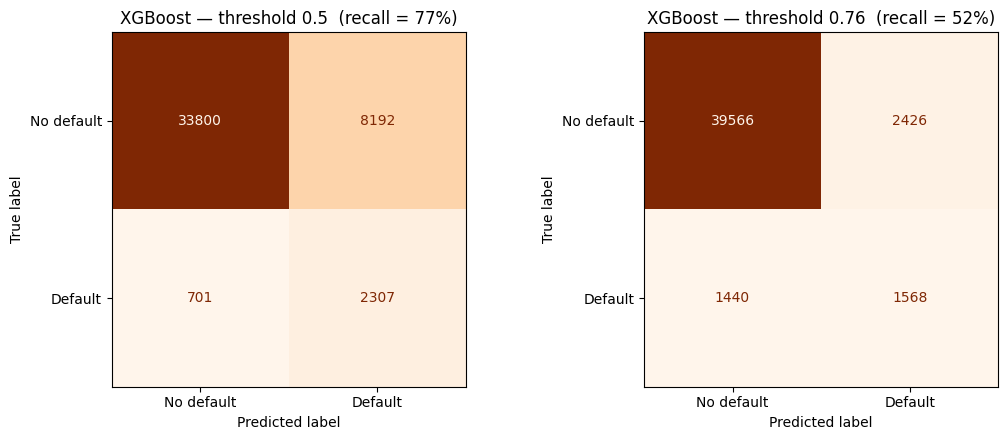

              precision    recall  f1-score   support

  No default      0.965     0.942     0.953     41992
     Default      0.393     0.521     0.448      3008

    accuracy                          0.914     45000
   macro avg      0.679     0.732     0.701     45000
weighted avg      0.927     0.914     0.920     45000



In [54]:
from sklearn.metrics import f1_score

proba_xgb = xgb.predict_proba(X_test)[:, 1]

# XGBOOST SWEEP of treshold it is simply in other scale
print(f"{'thr':>5} {'TP':>5} {'FN':>5} {'FP':>6} {'prec':>6} {'recall':>7} {'F1':>6} {'%port':>7}")
for t in [0.2, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    pred = (proba_xgb > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{t:>5} {tp:>5} {fn:>5} {fp:>6} {tp/(tp+fp):>6.3f} {tp/(tp+fn):>7.3f} "
          f"{f1_score(y_test, pred):>6.3f} {pred.mean():>6.1%}")

# best treshold F1
ths = np.arange(0.05, 0.99, 0.01)
f1s = [f1_score(y_test, (proba_xgb > t).astype(int)) for t in ths]
best_xgb = ths[int(np.argmax(f1s))]
print(f"\nBest F1 threshold for XGBoost: {best_xgb:.2f} (F1={max(f1s):.3f})")

# Print matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, t in zip(axes, [0.5, round(best_xgb, 2)]):
    cm = confusion_matrix(y_test, (proba_xgb > t).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(
        ax=ax, cmap="Oranges", colorbar=False, values_format="d")
    ax.set_title(f"XGBoost — threshold {t}  (recall = {cm[1,1]/y_test.sum():.0%})")
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba_xgb > best_xgb).astype(int),
                            target_names=["No default", "Default"], digits=3))

Interesting, XGBOOST can recall about 52% of Defaulters without 'bothering' o even declining too many False Positive clients

## Comparing XGBOOST and RF

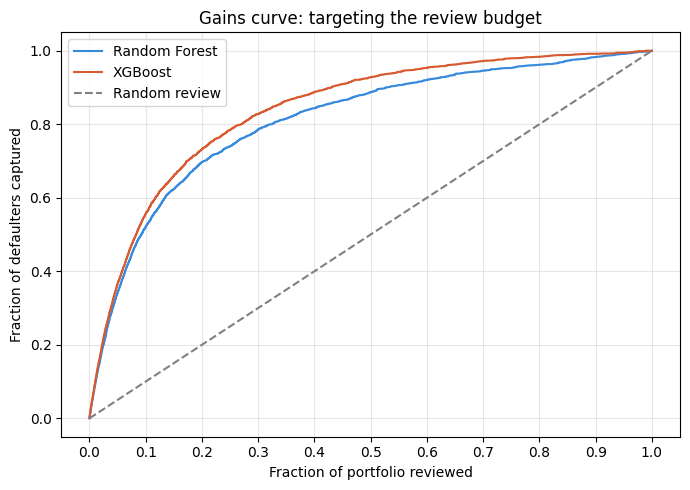

In [55]:
plt.figure(figsize=(7,5))
for nombre, p, color in [("Random Forest", proba_rf, "#378ADD"),
                         ("XGBoost", proba_xgb, "#D85A30")]:
    orden     = np.argsort(p)[::-1]              # sort by risk
    y_ord     = y_test.values[orden]
    capturado = np.cumsum(y_ord) / y_ord.sum()   # percentage of defaulters
    revisado  = np.arange(1, len(y_ord)+1) / len(y_ord)
    plt.plot(revisado, capturado, label=nombre, color=color)

plt.plot([0,1], [0,1], '--', color="gray", label="Random review")
plt.xlabel("Fraction of portfolio reviewed")
plt.ylabel("Fraction of defaulters captured")
plt.title("Gains curve: targeting the review budget")
plt.xticks(np.arange(0, 1.1, 0.1))
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


# Conclusion: Findings

Data Analysis:
- RUOUL > 1 is not noise, it's signal.
- NumberOfTimes90DaysLate had some impossible numbers, however they had a default ratio of 54%, they have strong signal, deleting those rows would be a mistake. Instead I substitute their value for the real max.
- Debt Ratio encompassed two variables. The majority had a correct ratio but for no income clients it had directly their amount of Debt
- Informative income missing clients.
- **Main Decision maker criteria for cleaning : Effect of given set of variable range to the Target Signal**

## **RESULTS**
- XGBoost ROC-AUC 0.866 / PR-AUC 0.401
- RF: 0.839 / 0.350
- Modest improvement using XGBoost compared to Random Forest
- Threshold is a business decision, **RECOMMENDATION: take THRESHOLD_RF $\ge 0.2$ as Defaulters for RF and THRESHOLD_XGB $\ge 0.76$ for XGBOOST**, this catches $\approx 50 \%$ of Defaulters, however it increases the number of False Positives. (They live in different scales, but correspond to each other:  scale_pos_weight)
- Checking the riskiest 10% the model catches about half 55% of Defaulters (See last Graph)

### Future Perspectives:
- The Next Layer would be classifiying by expected monetary loss instead probability, but this dataset does not include all necesary data for that but that would be the correct policy decision. This notebook is still actively being improved and updated. Last update: July 25 2026